In [2]:
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.utils import make_grid
from einops import repeat, rearrange

from sde_lib import MNISTSampler, GaussianConditionalProbabilityPath, LinearAlpha, LinearBeta, MNISTUNet, CFGTrainer, CFGVectorFieldODE, EulerSimulator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

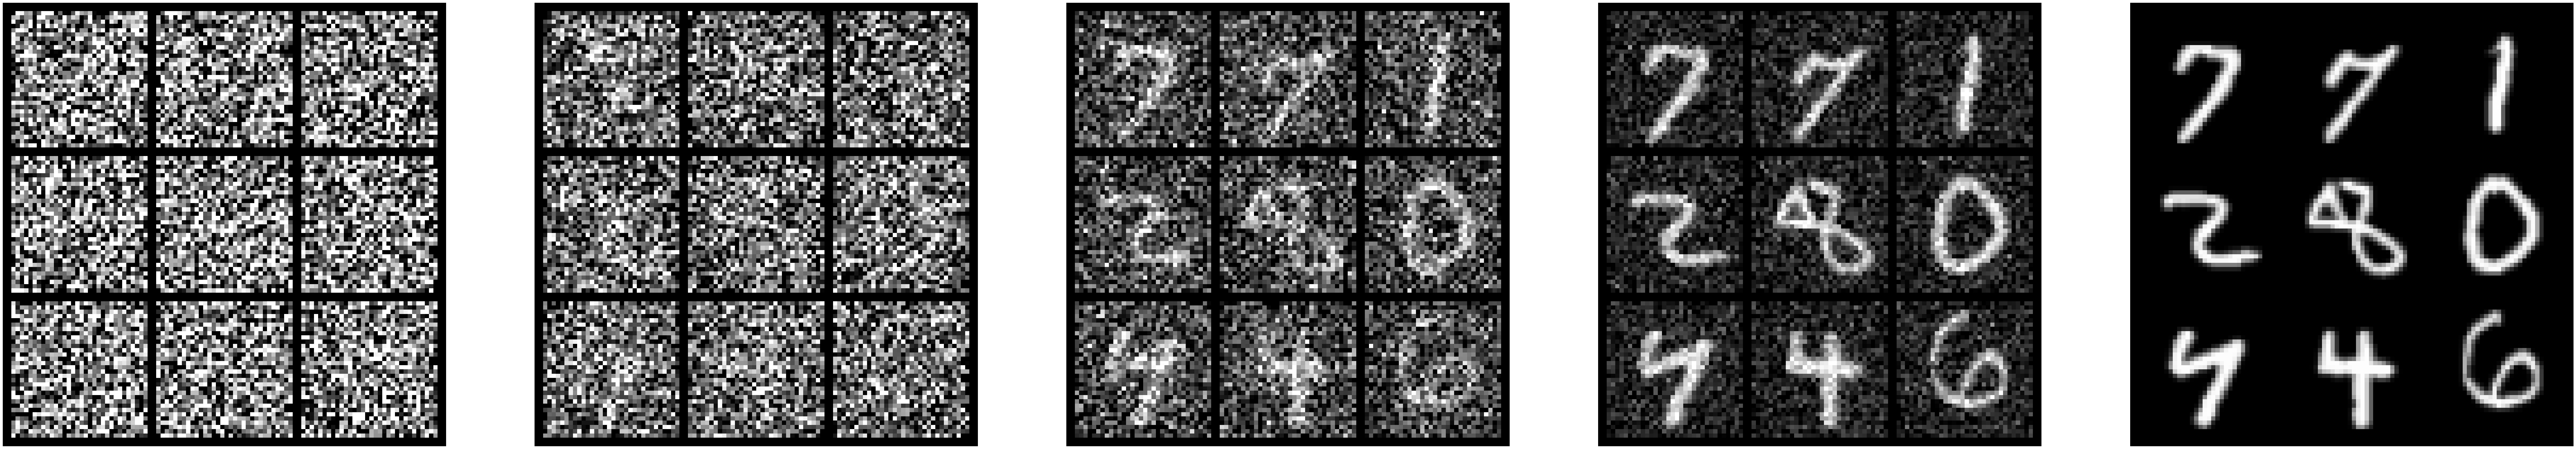

In [2]:
num_rows = 3
num_cols =3
num_samples = num_rows * num_cols
num_timesteps = 5
sampler = MNISTSampler().to(device)
path = GaussianConditionalProbabilityPath(p_data=MNISTSampler(), p_simple_shape=[1, 32, 32], alpha=LinearAlpha(), beta=LinearBeta()).to(device)
z, _ = path.p_data.sample(num_samples)

fig, axes = plt.subplots(1, num_timesteps, figsize=(8 * num_cols * num_timesteps, 8 * num_rows))
ts = torch.linspace(0, 1, num_timesteps).to(device)
for tidx, t in enumerate(ts):
    tt = repeat(t, '-> b 1 1 1', b=num_samples)  # (num_samples, 1, 1, 1)
    xt = path.sample_conditional_path(z, tt)  # (num_samples, 1, 32, 32)
    grid = make_grid(xt, nrow=num_cols, normalize=True, value_range=(-1,1))
    grid_hwc = rearrange(grid, 'c h w -> h w c')  # (H, W, C)
    axes[tidx].imshow(grid_hwc.cpu(), cmap="gray")
    axes[tidx].axis("off")
plt.show()

In [4]:
path = GaussianConditionalProbabilityPath(
    p_data=MNISTSampler(), 
    p_simple_shape=[1, 32, 32], 
    alpha=LinearAlpha(), 
    beta=LinearBeta()
).to(device)

unet = MNISTUNet(
    channels=[32, 64, 128], 
    num_residual_layers=2, 
    t_embed_dim=40, 
    y_embed_dim=40
).to(device)

trainer = CFGTrainer(path=path, model=unet, eta=0.1, device=device)

losses = trainer.train(num_epochs=5000, lr=1e-3, batch_size=250)

Training model with size: 4.715 MiB


Epoch 4999, loss: 143.55213928222656: : 5000it [4:36:19,  3.32s/it]


In [ ]:
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "mnist_cfg_unet_sde_lib.pth")
torch.save({
    'model_state_dict': unet.state_dict(),
    'optimizer_state_dict': trainer.get_optimizer(lr=1e-3).state_dict(),
    'losses': losses,
    'epoch': 5000,
    'model_config': {
        'channels': [32, 64, 128],
        'num_residual_layers': 2,
        't_embed_dim': 40,
        'y_embed_dim': 40
    }
}, checkpoint_path)
print(f"Model saved to: {checkpoint_path}")

Model saved to: checkpoints/mnist_cfg_unet_sde_lib.pth


In [5]:
checkpoint_dir = "checkpoints"
checkpoint_path = os.path.join(checkpoint_dir, "mnist_cfg_unet_sde_lib.pth")
loaded_checkpoint = torch.load(checkpoint_path, map_location=device)

unet = MNISTUNet(**loaded_checkpoint['model_config']).to(device)
unet.load_state_dict(loaded_checkpoint['model_state_dict'])
unet.eval()

print(f"Model loaded from: {checkpoint_path}")
print(f"Training epochs: {loaded_checkpoint['epoch']}")
print(f"Final loss: {loaded_checkpoint['losses'][-1]:.4f}")

Model loaded from: checkpoints/mnist_cfg_unet_sde_lib.pth
Training epochs: 5000
Final loss: 143.5521


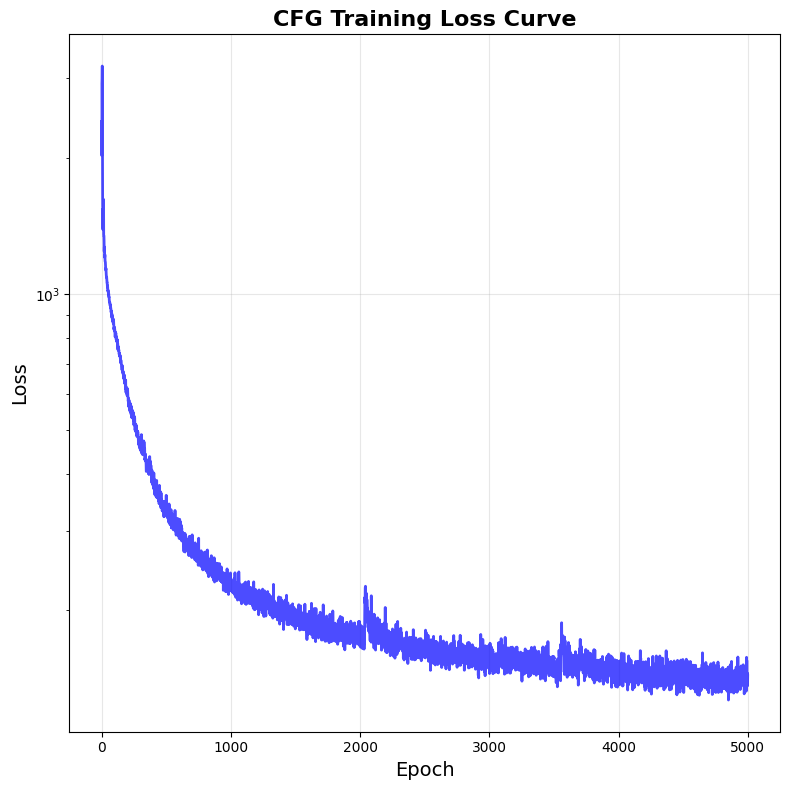

Initial loss: 2406.0391
Final loss: 143.5521
Loss reduction: 94.03%


In [6]:
# Plot training loss curve
plt.figure(figsize=(8, 8))
plt.plot(losses, linewidth=2, color='blue', alpha=0.7)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('CFG Training Loss Curve', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Use log scale for better visualization
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss reduction: {(1 - losses[-1]/losses[0])*100:.2f}%")


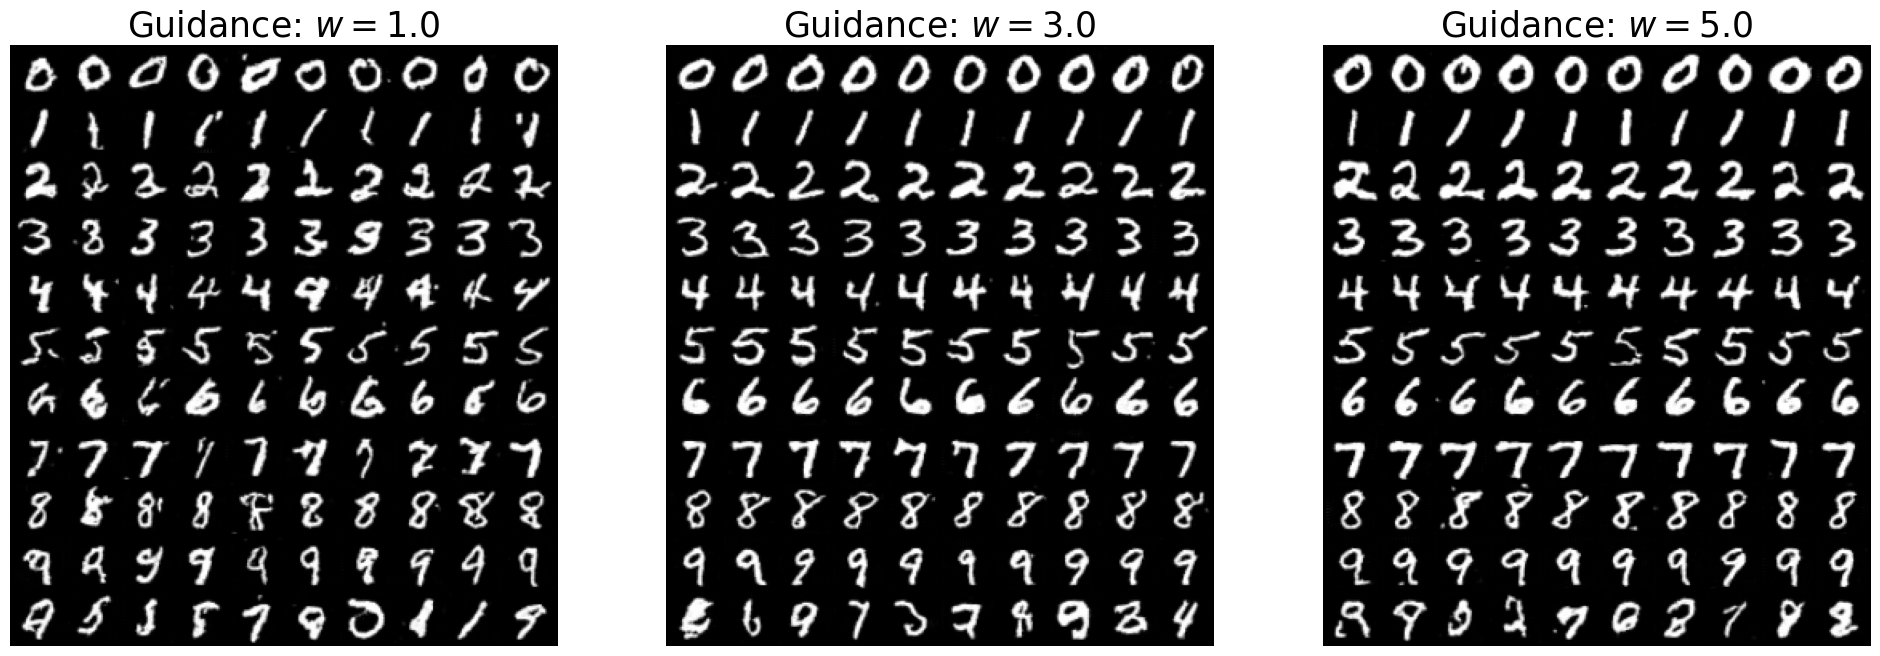

In [ ]:
samples_per_class = 10
num_timesteps = 100
guidance_scales = [1.0, 3.0, 5.0]
path = GaussianConditionalProbabilityPath(
    p_data=MNISTSampler(), 
    p_simple_shape=[1, 32, 32], 
    alpha=LinearAlpha(), 
    beta=LinearBeta()
).to(device)

fig, axes = plt.subplots(1, len(guidance_scales), figsize=(8 * len(guidance_scales), 8))

for idx, w in enumerate(guidance_scales):
    ode = CFGVectorFieldODE(unet, guidance_scale=w)
    simulator = EulerSimulator(ode)
    # Sample initial conditions
    y = repeat(torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.int64), 
               'n -> (n repeat)', repeat=samples_per_class).to(device)
    num_samples = y.shape[0]
    x0, _ = path.p_simple.sample(num_samples) # (num_samples, 1, 32, 32)
    # Simulate
    ts = repeat(torch.linspace(0, 1, num_timesteps), 
                't -> b t 1 1 1', b=num_samples).to(device)
    x1 = simulator.simulate(x0, ts, y=y)
    # Plot
    grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(-1,1))
    grid_hwc = rearrange(grid, 'c h w -> h w c')
    axes[idx].imshow(grid_hwc.cpu(), cmap="gray")
    axes[idx].axis("off")
    axes[idx].set_title(f"Guidance: $w={w:.1f}$", fontsize=25)
plt.show()
